# 14. Stage 1 Extended Rule Evaluation

## 0. 실험 목적 및 원칙

이 실험은 LLM을 사용하기 전에 일반화 가능한 명시적 Rule만 확장했을 때 실제 사용자 자연어를 어디까지 처리할 수 있는지 측정한다.

- 기존 11번 Parser와 13번 Baseline은 수정하지 않는다.
- 13번과 동일한 Golden Set 200개, normalization, Exact Match, Micro F1, Positive-only 정의를 사용한다.
- Rule은 Golden Query 예측 전에 고정하며, Query별 예외를 추가하지 않는다.
- 감성·장면·직업·상황 표현을 임의의 향 Feature로 변환하지 않는다.
- LLM, embedding, 외부 API, 향수 Ranking을 사용하지 않는다.
- 이 200개는 개발용 평가 성격이 있으며 최종 일반화 성능은 별도 외부 Query에서 검증해야 한다.

## 1. Environment & Imports

In [1]:
import collections
import hashlib
import json
import pathlib
import re
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 160)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

## 2. Path Configuration

In [2]:
PROJECT_ROOT = pathlib.Path.cwd().resolve()
OUTPUT_DIR = PROJECT_ROOT / "analysis_outputs"
GOLDSET_PATH = PROJECT_ROOT / "evaluation_data" / "stage1" / "13_stage1_golden_set_v1_200.xlsx"
LEXICON_PATH = OUTPUT_DIR / "11_rule_lexicon.csv"
BASELINE_METRICS_PATH = OUTPUT_DIR / "13_rule_stage1_metrics.csv"
BASELINE_EVALUATION_PATH = OUTPUT_DIR / "13_rule_stage1_evaluation.csv"
BASELINE_ERRORS_PATH = OUTPUT_DIR / "13_rule_stage1_errors.csv"

PROTECTED_PATHS = {
    "11 notebook": PROJECT_ROOT / "11_rule_based_query_retrieval_baseline.ipynb",
    "13 notebook": PROJECT_ROOT / "13_stage1_rule_baseline_evaluation.ipynb",
    "Golden Set": GOLDSET_PATH,
    "13 predictions": OUTPUT_DIR / "13_rule_stage1_predictions.csv",
    "13 evaluation": BASELINE_EVALUATION_PATH,
    "13 errors": BASELINE_ERRORS_PATH,
    "13 metrics": BASELINE_METRICS_PATH,
    "13 summary": OUTPUT_DIR / "13_rule_stage1_summary.md",
}
required_paths = {**PROTECTED_PATHS, "11 Rule Lexicon": LEXICON_PATH}
for label, path in required_paths.items():
    if not path.is_file():
        raise FileNotFoundError(f"필수 파일이 없습니다 - {label}: {path}")


def sha256_file(path):
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


protected_hashes_before = {label: sha256_file(path) for label, path in PROTECTED_PATHS.items()}
OUTPUT_DIR.mkdir(exist_ok=True)
display(pd.DataFrame([
    {"label": label, "path": str(path), "exists": path.is_file()}
    for label, path in required_paths.items()
]))

,label,path,exists
0,11 notebook,C:\Users\SSAFY\Desktop\archive\11_rule_based_query_retrieval_baseline.ipynb,True
1,13 notebook,C:\Users\SSAFY\Desktop\archive\13_stage1_rule_baseline_evaluation.ipynb,True
2,Golden Set,C:\Users\SSAFY\Desktop\archive\evaluation_data\stage1\13_stage1_golden_set_v1_200.xlsx,True
3,13 predictions,C:\Users\SSAFY\Desktop\archive\analysis_outputs\13_rule_stage1_predictions.csv,True
4,13 evaluation,C:\Users\SSAFY\Desktop\archive\analysis_outputs\13_rule_stage1_evaluation.csv,True
5,13 errors,C:\Users\SSAFY\Desktop\archive\analysis_outputs\13_rule_stage1_errors.csv,True
6,13 metrics,C:\Users\SSAFY\Desktop\archive\analysis_outputs\13_rule_stage1_metrics.csv,True
7,13 summary,C:\Users\SSAFY\Desktop\archive\analysis_outputs\13_rule_stage1_summary.md,True
8,11 Rule Lexicon,C:\Users\SSAFY\Desktop\archive\analysis_outputs\11_rule_lexicon.csv,True


## 3. Load Baseline Results

Rule 정의 전에 읽는 Baseline 정보는 집계 지표뿐이다. Query, Gold, 오류 사례는 Extended Prediction이 끝난 뒤 비교 단계에서만 읽는다.

In [3]:
baseline_metrics_df = pd.read_csv(BASELINE_METRICS_PATH)
if baseline_metrics_df.columns.tolist() != ["metric", "value"]:
    raise ValueError("13번 metric 파일 스키마가 예상과 다릅니다.")
if baseline_metrics_df["metric"].duplicated().any():
    raise ValueError("13번 metric 이름이 중복됩니다.")
baseline_metric = baseline_metrics_df.set_index("metric")["value"]

required_baseline_metrics = [
    "overall_exact_match", "any_condition_prediction_coverage",
    "positive_scent_micro_f1", "parser_error_count",
]
missing_baseline_metrics = [name for name in required_baseline_metrics if name not in baseline_metric]
if missing_baseline_metrics:
    raise ValueError(f"13번 metric 누락: {missing_baseline_metrics}")

display(baseline_metric.loc[required_baseline_metrics].to_frame("current_rule"))

,current_rule
metric,
overall_exact_match,0.0150
any_condition_prediction_coverage,0.1550
positive_scent_micro_f1,0.4590
parser_error_count,0.0000


## 4. Define Extended Rule Policy

### 처리하는 표현

- `남자`, `여성용`, `유니섹스`처럼 명확한 성별 타깃 표현
- `은은한`, `진한 향`, `적당한 강도`처럼 향 강도를 직접 말한 표현
- `오래가는`, `지속력이 짧은`처럼 지속 시간을 직접 말한 표현
- `싫어`, `별로`, `말고`, `제외`, `하지 않은`처럼 명시된 회피 표현
- 기존 Fragrantica Feature와 의미가 직접 같은 소수의 한국어 향 이름

### 처리하지 않는 표현

- 비 오는 숲, 고급 호텔, 차가운 도시, 포근한 분위기 같은 장면·감성 표현
- 소개팅, 금융맨, 공주, 직장인 같은 상황·직업·이미지 표현
- 머리가 안 아픈, 편안한, 자연스러운, 깔끔한 같은 표현의 임의 강도 변환
- Additional Requirements의 장면·가격·나이·제품 비교 요구

Community gender는 생물학적 성별 판정이 아니라 향수의 성별 인식 또는 타깃 표현에 가까운 값으로 해석한다.

### 충돌 우선순위

1. 명시적 부정 범위에 포함된 향은 preference에서 제거하고 avoid에 둔다.
2. 같은 향의 긍정 언급이 별도로 있으면 preference와 avoid에 각각 보존한다.
3. 강도 표현이 여러 개면 `너무 세지도 약하지도 않은` 같은 명시적 MEDIUM을 우선하고, 그 외에는 문장 뒤쪽의 직접 표현을 사용한다.

In [4]:
# 이 셀의 Rule 정의는 Golden Set을 로드하기 전에 고정된다.
GENDER_RULES = [
    ("neuter", r"중성적인|유니섹스|남녀\s*공용"),
    ("male", r"남성용|남성|남자용|남자가\s*쓰(?:기|는)\s*좋은|남자"),
    ("female", r"여성용|여성|여자용|여자가\s*쓰(?:기|는)\s*좋은|여자"),
]

INTENSITY_RULES = [
    ("MEDIUM", r"적당한\s*(?:향\s*)?(?:강도|세기)"),
    ("MEDIUM", r"너무\s*(?:세|강하)지도\s*약하지도\s*않은"),
    ("LOW", r"은은한|은은하게"),
    ("LOW", r"향이?\s*(?:세|강하)지\s*않(?:은|게|았으면|기를)"),
    ("LOW", r"너무\s*(?:세|강하)지\s*않(?:은|게|았으면)"),
    ("LOW", r"약한\s*향|향이\s*약한"),
    ("LOW", r"부담스럽지\s*않게\s*퍼지는"),
    ("LOW", r"발향(?:력|력이)?\s*약한"),
    ("HIGH", r"강한\s*향|향이\s*강한"),
    ("HIGH", r"진한\s*향"),
    ("HIGH", r"존재감\s*있는\s*향"),
    ("HIGH", r"향이\s*확실히\s*나는"),
    ("HIGH", r"발향(?:력|력이)?\s*(?:좋은|강한)"),
]

LONGEVITY_RULES = [
    ("HIGH", r"오래\s*가는|오래가는"),
    ("HIGH", r"오래\s*지속(?:되는|됐으면|되었으면)"),
    ("HIGH", r"지속력(?:이)?\s*(?:좋은|좋았으면|길(?:은|었으면))"),
    ("HIGH", r"지속성(?:이)?\s*(?:좋은|좋았으면)"),
    ("HIGH", r"하루\s*종일\s*(?:가는|지속되는)"),
    ("HIGH", r"잔향이\s*오래\s*남는"),
    ("LOW", r"금방\s*사라지는"),
    ("LOW", r"지속력(?:이)?\s*짧은"),
    ("LOW", r"짧게\s*남는"),
    ("LOW", r"오래\s*가지\s*않는"),
]

# Fragrantica Note와 뜻이 직접 같은 보수적인 한국어 별칭만 사용한다.
DIRECT_SCENT_RULES = [
    {"pattern": r"바닐라", "feature": "Vanilla", "replace_existing": ["vanilla"]},
    {"pattern": r"장미", "feature": "Rose", "replace_existing": []},
    {"pattern": r"민트", "feature": "Mint", "replace_existing": []},
    {"pattern": r"레몬(?!\s*(?:껍질|제스트))", "feature": "Lemon", "replace_existing": []},
]

rule_definition_rows = []
for value, pattern in GENDER_RULES:
    rule_definition_rows.append(("gender", value, pattern))
for value, pattern in INTENSITY_RULES:
    rule_definition_rows.append(("intensity", value, pattern))
for value, pattern in LONGEVITY_RULES:
    rule_definition_rows.append(("longevity", value, pattern))
for item in DIRECT_SCENT_RULES:
    rule_definition_rows.append(("direct_scent", item["feature"], item["pattern"]))
rule_definition_df = pd.DataFrame(rule_definition_rows, columns=["rule_group", "output", "pattern"])
display(rule_definition_df)

,rule_group,output,pattern
0,gender,neuter,중성적인|유니섹스|남녀\s*공용
1,gender,male,남성용|남성|남자용|남자가\s*쓰(?:기|는)\s*좋은|남자
2,gender,female,여성용|여성|여자용|여자가\s*쓰(?:기|는)\s*좋은|여자
3,intensity,MEDIUM,적당한\s*(?:향\s*)?(?:강도|세기)
4,intensity,MEDIUM,너무\s*(?:세|강하)지도\s*약하지도\s*않은
5,intensity,LOW,은은한|은은하게
6,intensity,LOW,향이?\s*(?:세|강하)지\s*않(?:은|게|았으면|기를)
7,intensity,LOW,너무\s*(?:세|강하)지\s*않(?:은|게|았으면)
8,intensity,LOW,약한\s*향|향이\s*약한
9,intensity,LOW,부담스럽지\s*않게\s*퍼지는


## 5. Load Existing Rule Parser

In [5]:
def normalize_text(text):
    text = unicodedata.normalize("NFKC", str(text)).casefold()
    return re.sub(r"\s+", " ", text).strip()


rule_lexicon_df = pd.read_csv(LEXICON_PATH, dtype=str, keep_default_na=False)
expected_lexicon_columns = {
    "surface_form", "normalized_form", "feature_type",
    "feature_name", "mapping_type", "evidence_level",
}
if set(rule_lexicon_df.columns) != expected_lexicon_columns:
    raise ValueError("11번 Rule Lexicon 스키마가 예상과 다릅니다.")

rules_by_surface = collections.defaultdict(list)
for row in rule_lexicon_df.to_dict("records"):
    rules_by_surface[row["normalized_form"]].append(row)
sorted_surfaces = sorted(rules_by_surface, key=lambda value: (-len(value), value))


def spans_overlap(span, occupied):
    start, end = span
    return any(start < used_end and used_start < end for used_start, used_end in occupied)


def surface_matches(normalized_query, surface):
    escaped = re.escape(surface)
    if re.search(r"[a-z0-9]", surface):
        pattern = rf"(?<![a-z0-9]){escaped}(?![a-z0-9])"
    else:
        pattern = escaped
    return list(re.finditer(pattern, normalized_query))


def choose_rule(candidates, original_fragment, after_text):
    by_type = collections.defaultdict(list)
    for candidate in candidates:
        by_type[candidate["feature_type"]].append(candidate)
    if "NOTE" in by_type and re.search(r"^\s*(노트|note)", after_text):
        return by_type["NOTE"][0]
    if "ACCORD" in by_type and re.search(r"^\s*(향|accord)", after_text):
        return by_type["ACCORD"][0]
    if "SEASON" in by_type:
        return by_type["SEASON"][0]
    if "DAYPART" in by_type:
        return by_type["DAYPART"][0]
    if len(by_type) == 1:
        return candidates[0]
    if "NOTE" in by_type and any(character.isupper() for character in original_fragment):
        return by_type["NOTE"][0]
    if "ACCORD" in by_type:
        return by_type["ACCORD"][0]
    return candidates[0]


def parse_existing_rules(query):
    normalized_query = normalize_text(query)
    occupied = []
    resolved_matches = []
    for surface in sorted_surfaces:
        for match in surface_matches(normalized_query, surface):
            if spans_overlap(match.span(), occupied):
                continue
            original_fragment = str(query)[match.start():match.end()]
            after_text = normalized_query[match.end():match.end() + 12]
            chosen = choose_rule(rules_by_surface[surface], original_fragment, after_text)
            resolved_matches.append({
                "start": match.start(), "end": match.end(),
                "surface": surface, "chosen": chosen,
            })
            occupied.append(match.span())

    result = {"accords": [], "notes": [], "seasons": [], "dayparts": []}
    target_key = {"ACCORD": "accords", "NOTE": "notes", "SEASON": "seasons", "DAYPART": "dayparts"}
    for item in sorted(resolved_matches, key=lambda value: value["start"]):
        chosen = item["chosen"]
        key = target_key[chosen["feature_type"]]
        value = chosen["feature_name"]
        if value not in result[key]:
            result[key].append(value)
    return result, resolved_matches


print(f"재사용하는 고정 Rule Lexicon: {len(rule_lexicon_df):,}개")

재사용하는 고정 Rule Lexicon: 2,638개


## 6. Gender Rules

In [6]:
def deduplicate_preserving_order(values):
    seen = set()
    result = []
    for value in values:
        key = normalize_text(value)
        if key not in seen:
            seen.add(key)
            result.append(value)
    return result


def parse_gender(query):
    normalized_query = normalize_text(query)
    matches = []
    for value, pattern in GENDER_RULES:
        for match in re.finditer(pattern, normalized_query):
            matches.append((match.start(), value))
    return deduplicate_preserving_order(value for _, value in sorted(matches))

## 7. Intensity Rules

In [7]:
NEGATION_AFTER_PATTERN = re.compile(
    r"^\s*(?:향|노트|계열)?\s*(?:건|것은|것을|은|는|이|가|을|를)?\s*"
    r"(?:싫|별로|말고|제외|빼고|피하|원하지\s*않|안\s*좋|아니|않)"
)
NEGATION_BEFORE_PATTERN = re.compile(r"(?:싫어하는|피하고\s*싶은|원하지\s*않는)\s*$")


def is_negated_span(normalized_query, start, end):
    before = normalized_query[max(0, start - 20):start]
    after = normalized_query[end:end + 30]
    return bool(NEGATION_AFTER_PATTERN.search(after) or NEGATION_BEFORE_PATTERN.search(before))


def parse_scalar_rules(query, rules, medium_priority=False):
    normalized_query = normalize_text(query)
    matches = []
    for value, pattern in rules:
        for match in re.finditer(pattern, normalized_query):
            if is_negated_span(normalized_query, match.start(), match.end()):
                continue
            matches.append((match.start(), value, match.group(0)))
    if not matches:
        return "", []
    if medium_priority:
        medium_matches = [item for item in matches if item[1] == "MEDIUM"]
        if medium_matches:
            chosen = sorted(medium_matches)[-1]
            return chosen[1], matches
    chosen = sorted(matches)[-1]
    return chosen[1], matches


def parse_intensity(query):
    return parse_scalar_rules(query, INTENSITY_RULES, medium_priority=True)

## 8. Longevity Rules

In [8]:
def parse_longevity(query):
    return parse_scalar_rules(query, LONGEVITY_RULES, medium_priority=False)

## 9. Avoid Rules

In [9]:
AVOID_CAPTURE_PATTERNS = [
    re.compile(
        r"(?P<term>[^,.!?;]{1,45}?)(?:건|것은|것을|은|는|이|가|을|를)\s*"
        r"(?:정말\s*)?(?:싫|별로|말고|제외|빼고|피하|원하지\s*않)"
    ),
    re.compile(r"(?P<term>[^,.!?;]{1,35}?)\s*말고"),
    re.compile(r"(?P<term>[가-힣a-z0-9 ]{1,25}?)하지\s*않(?:은|는|았으면)"),
    re.compile(r"(?P<term>[가-힣a-z0-9 ]{1,25}?)\s*없는\s*(?:향|향수)"),
]


def clean_avoid_term(term):
    term = normalize_text(term).strip(" '\"“”‘’/()[]")
    contrast_parts = re.split(r"(?:좋은데|좋지만|원하지만|하지만|그런데|근데|다만)", term)
    term = contrast_parts[-1].strip()
    term = re.sub(r"^(?:나는|난|저는|전|그리고)\s+", "", term).strip()
    term = re.sub(r"\s+(?:건|것)$", "", term).strip()
    return term


extended_alias_lookup = {}
for item in DIRECT_SCENT_RULES:
    # 단순 별칭 Rule의 표면형만 canonical lookup에 사용한다.
    surface = item["pattern"].split("(")[0]
    extended_alias_lookup[normalize_text(surface)] = item["feature"]


def canonicalize_avoid_term(term):
    cleaned = clean_avoid_term(term)
    if not cleaned:
        return ""
    scent_surface = re.sub(r"\s*(?:향기|향|노트|계열)$", "", cleaned).strip()
    if scent_surface in extended_alias_lookup:
        return extended_alias_lookup[scent_surface]
    candidates = rules_by_surface.get(scent_surface, [])
    scent_candidates = [row for row in candidates if row["feature_type"] in {"ACCORD", "NOTE"}]
    if scent_candidates:
        chosen = choose_rule(scent_candidates, scent_surface, "")
        return chosen["feature_name"]
    return cleaned


def parse_generic_avoid(query):
    normalized_query = normalize_text(query)
    matches = []
    for pattern in AVOID_CAPTURE_PATTERNS:
        for match in pattern.finditer(normalized_query):
            value = canonicalize_avoid_term(match.group("term"))
            if value and len(value) <= 45:
                matches.append((match.start(), value))
    return deduplicate_preserving_order(value for _, value in sorted(matches))

## 10. Extended Direct Scent Rules

In [10]:
def parse_extended_scent(query):
    normalized_query = normalize_text(query)
    positive = []
    negative = []
    replace_existing = set()
    any_alias_match = False
    for item in DIRECT_SCENT_RULES:
        for match in re.finditer(item["pattern"], normalized_query):
            any_alias_match = True
            replace_existing.update(item["replace_existing"])
            target = negative if is_negated_span(normalized_query, match.start(), match.end()) else positive
            target.append((match.start(), item["feature"]))
    return (
        deduplicate_preserving_order(value for _, value in sorted(positive)),
        deduplicate_preserving_order(value for _, value in sorted(negative)),
        replace_existing,
        any_alias_match,
    )


def existing_scent_polarity(query, resolved_matches):
    normalized_query = normalize_text(query)
    positive = collections.defaultdict(list)
    negative = collections.defaultdict(list)
    for item in resolved_matches:
        chosen = item["chosen"]
        if chosen["feature_type"] not in {"ACCORD", "NOTE"}:
            continue
        bucket = negative if is_negated_span(normalized_query, item["start"], item["end"]) else positive
        bucket[chosen["feature_name"]].append(item["start"])
    return set(positive), set(negative), [
        (min(positions), feature) for feature, positions in negative.items()
    ]

## 11. Merge Rule Outputs

In [11]:
def merge_stage1_predictions(query):
    existing, resolved_matches = parse_existing_rules(query)
    gender = parse_gender(query)
    intensity, intensity_matches = parse_intensity(query)
    longevity, longevity_matches = parse_longevity(query)
    direct_positive, direct_negative, replace_existing, direct_alias_matched = parse_extended_scent(query)
    existing_positive, existing_negative, existing_negative_positions = existing_scent_polarity(query, resolved_matches)

    existing_scent = existing["accords"] + existing["notes"]
    suppressed = {
        feature for feature in existing_negative
        if feature not in existing_positive
    } | replace_existing
    scent_preference = [feature for feature in existing_scent if feature not in suppressed]
    scent_preference = deduplicate_preserving_order(scent_preference + direct_positive)

    avoid_items = [value for _, value in sorted(existing_negative_positions)]
    avoid_items.extend(direct_negative)
    avoid_items.extend(parse_generic_avoid(query))
    avoid_items = deduplicate_preserving_order(avoid_items)

    triggers = []
    if gender:
        triggers.append("gender")
    if intensity:
        triggers.append("intensity")
    if longevity:
        triggers.append("longevity")
    if avoid_items:
        triggers.append("avoid")
    if direct_alias_matched and direct_positive:
        triggers.append("extended_scent")

    prediction = {
        "scent_preference": scent_preference,
        "context": {
            "season": list(existing["seasons"]),
            "daypart": list(existing["dayparts"]),
            "gender": gender,
        },
        "performance": {"intensity": intensity, "longevity": longevity},
        "avoid": avoid_items,
        "additional_requirements": [],
    }
    return prediction, triggers


architecture_df = pd.DataFrame([
    ("existing_rule_parser", "accord / note / season / daypart"),
    ("extended_rule_parser", "gender / intensity / longevity / avoid / direct scent"),
    ("merge_stage1_predictions", "부정 범위와 canonical 충돌 처리"),
], columns=["stage", "responsibility"])
display(architecture_df)

,stage,responsibility
0,existing_rule_parser,accord / note / season / daypart
1,extended_rule_parser,gender / intensity / longevity / avoid / direct scent
2,merge_stage1_predictions,부정 범위와 canonical 충돌 처리


## 12. Load & Validate Golden Set

이 지점부터 Golden Set을 로드한다. 앞의 Rule 정의는 이미 고정됐으며 이후 Rule을 변경하지 않는다.

In [12]:
JSON_COLUMNS = [
    "gold_scent_preference", "gold_context", "gold_performance",
    "gold_avoid", "gold_additional_requirements",
]
EXPECTED_COLUMNS = ["query_id", "query_text", *JSON_COLUMNS]


def load_goldset(path=GOLDSET_PATH):
    return pd.read_excel(path, sheet_name="Golden Set", header=4, dtype=str, keep_default_na=False)


def parse_json_cell(value, query_id, column):
    try:
        return json.loads(value)
    except (TypeError, json.JSONDecodeError) as exc:
        raise ValueError(f"JSON parsing 실패: query_id={query_id}, column={column}") from exc


def validate_goldset(frame):
    if frame.columns.tolist() != EXPECTED_COLUMNS:
        raise ValueError(f"Golden Set 컬럼 불일치: {frame.columns.tolist()}")
    if len(frame) != 200:
        raise ValueError(f"Golden Set은 200개여야 합니다: {len(frame)}")
    if frame["query_id"].duplicated().any() or frame["query_text"].duplicated().any():
        raise ValueError("query_id 또는 query_text가 중복됩니다.")
    parsed = frame.copy()
    for column in JSON_COLUMNS:
        parsed[column] = [
            parse_json_cell(value, query_id, column)
            for value, query_id in zip(frame[column], frame["query_id"])
        ]
    for row in parsed.itertuples(index=False):
        if not isinstance(row.gold_scent_preference, list):
            raise TypeError(f"{row.query_id}: scent는 list여야 합니다.")
        if set(row.gold_context) != {"season", "daypart", "gender"}:
            raise ValueError(f"{row.query_id}: context key 불일치")
        if set(row.gold_performance) != {"intensity", "longevity"}:
            raise ValueError(f"{row.query_id}: performance key 불일치")
        if not isinstance(row.gold_avoid, list) or not isinstance(row.gold_additional_requirements, list):
            raise TypeError(f"{row.query_id}: avoid/additional은 list여야 합니다.")
    return parsed


gold_df = validate_goldset(load_goldset())
print(f"Golden Set Query count: {len(gold_df)}")
print(f"Unique query_id count: {gold_df['query_id'].nunique()}")
print(f"Unique query_text count: {gold_df['query_text'].nunique()}")

Golden Set Query count: 200


Unique query_id count: 200
Unique query_text count: 200


## 13. Run Extended Parser

In [13]:
def run_extended_parser(queries):
    rows = []
    parser_errors = []
    empty = {
        "scent_preference": [],
        "context": {"season": [], "daypart": [], "gender": []},
        "performance": {"intensity": "", "longevity": ""},
        "avoid": [], "additional_requirements": [],
    }
    for row in queries.itertuples(index=False):
        try:
            prediction, triggers = merge_stage1_predictions(row.query_text)
            parser_error = ""
        except Exception as exc:
            prediction, triggers = empty, []
            parser_error = f"{type(exc).__name__}: {exc}"
            parser_errors.append({"query_id": row.query_id, "query_text": row.query_text, "parser_error": parser_error})
        rows.append({
            "query_id": row.query_id,
            "query_text": row.query_text,
            "pred_scent_preference": prediction["scent_preference"],
            "pred_context": prediction["context"],
            "pred_performance": prediction["performance"],
            "pred_avoid": prediction["avoid"],
            "pred_additional_requirements": prediction["additional_requirements"],
            "trigger_rules": triggers,
            "parser_error": parser_error,
        })
    return pd.DataFrame(rows), pd.DataFrame(parser_errors, columns=["query_id", "query_text", "parser_error"])


queries_df = gold_df[["query_id", "query_text"]].copy()
predictions_df, parser_errors_df = run_extended_parser(queries_df)
if len(predictions_df) != 200 or predictions_df["query_id"].nunique() != 200:
    raise RuntimeError("200개 Query 예측이 완전하게 생성되지 않았습니다.")

print(f"처리된 Query: {len(predictions_df)}")
print(f"Parser 오류: {len(parser_errors_df)}")
display(predictions_df.head(10))

처리된 Query: 200
Parser 오류: 0


,query_id,query_text,pred_scent_preference,pred_context,pred_performance,pred_avoid,pred_additional_requirements,trigger_rules,parser_error
0,UQ0001,비가 온 뒤의 숲같은 향을 찾고 있어,[],"{'season': [], 'daypart': [], 'gender': []}","{'intensity': '', 'longevity': ''}",[],[],[],
1,UQ0002,시트러스 계열의 깔끔한 향의 향수가 있어?,[citrus],"{'season': [], 'daypart': [], 'gender': []}","{'intensity': '', 'longevity': ''}",[],[],[],
2,UQ0003,향수 가격 적당한 거 추천해줘. 그냥 구색 갖추려고 사는 거야.,[],"{'season': [], 'daypart': [], 'gender': []}","{'intensity': '', 'longevity': ''}",[],[],[],
3,UQ0004,"여성스러운 향을 사고 싶은데, 너무 달콤한 건 싫어. 그런 향기가 있을까?",[],"{'season': [], 'daypart': [], 'gender': ['female']}","{'intensity': '', 'longevity': ''}",[너무 달콤한],[],"[gender, avoid]",
4,UQ0005,난 바닐라 향기가 좋은데. 너무 단 건 싫어.,[Vanilla],"{'season': [], 'daypart': [], 'gender': []}","{'intensity': '', 'longevity': ''}",[너무 단],[],"[avoid, extended_scent]",
5,UQ0006,바다 냄새 나는 향수가 있나? 가능함?,[],"{'season': [], 'daypart': [], 'gender': []}","{'intensity': '', 'longevity': ''}",[],[],[],
6,UQ0007,30대 초반 남자가 쓰기 좋은 향수 추천해줘,[],"{'season': [], 'daypart': [], 'gender': ['male']}","{'intensity': '', 'longevity': ''}",[],[],[gender],
7,UQ0008,레몬 말고. 레몬 껍질 냄새나는 향수 있음?,[],"{'season': [], 'daypart': [], 'gender': []}","{'intensity': '', 'longevity': ''}",[Lemon],[],[avoid],
8,UQ0009,"중성적인 향수 뿌리고 싶어. 너무 여성스럽지 않되, 너무 남자 향수도 아니었으면 좋겠다.",[],"{'season': [], 'daypart': [], 'gender': ['neuter', 'female', 'male']}","{'intensity': '', 'longevity': ''}",[],[],[gender],
9,UQ0010,"케이크 같으면서도, 너무 느끼하지 않고, 딱 맡았을 때 공주처럼 느껴지는 향수 그런 거 없음?",[],"{'season': [], 'daypart': [], 'gender': []}","{'intensity': '', 'longevity': ''}",[],[],[],


## 14. Normalize

In [14]:
def normalize_scalar(value):
    return normalize_text(value)


def normalize_list(values):
    return frozenset(normalize_scalar(value) for value in values if normalize_scalar(value))


def normalize_context(value):
    return {
        "season": normalize_list(value["season"]),
        "daypart": normalize_list(value["daypart"]),
        "gender": normalize_list(value["gender"]),
    }


def normalize_performance(value):
    return {
        "intensity": normalize_scalar(value["intensity"]),
        "longevity": normalize_scalar(value["longevity"]),
    }


def json_text(value):
    return json.dumps(value, ensure_ascii=False, separators=(",", ":"))

## 15. Evaluate

In [15]:
def safe_divide(numerator, denominator):
    return numerator / denominator if denominator else 0.0


def evaluate_multilabel(gold_values, pred_values, mask=None):
    if mask is None:
        mask = np.ones(len(gold_values), dtype=bool)
    tp = fp = fn = eligible = 0
    for gold, pred, include in zip(gold_values, pred_values, mask):
        if not include:
            continue
        eligible += 1
        gold_set, pred_set = normalize_list(gold), normalize_list(pred)
        tp += len(gold_set & pred_set)
        fp += len(pred_set - gold_set)
        fn += len(gold_set - pred_set)
    precision = safe_divide(tp, tp + fp)
    recall = safe_divide(tp, tp + fn)
    f1 = safe_divide(2 * precision * recall, precision + recall)
    return {"precision": precision, "recall": recall, "f1": f1,
            "tp": tp, "fp": fp, "fn": fn, "eligible_queries": eligible}


def scalar_accuracy(gold_values, pred_values, mask=None):
    if mask is None:
        mask = np.ones(len(gold_values), dtype=bool)
    compared = [
        normalize_scalar(gold) == normalize_scalar(pred)
        for gold, pred, include in zip(gold_values, pred_values, mask) if include
    ]
    return {"accuracy": float(np.mean(compared)) if compared else np.nan,
            "eligible_queries": len(compared)}


def list_exact(gold, pred):
    return normalize_list(gold) == normalize_list(pred)


def context_exact(gold, pred):
    return normalize_context(gold) == normalize_context(pred)


def performance_exact(gold, pred):
    return normalize_performance(gold) == normalize_performance(pred)


merged_df = gold_df.merge(predictions_df, on=["query_id", "query_text"], how="left", validate="one_to_one")
evaluation_rows = []
for row in merged_df.itertuples(index=False):
    matches = {
        "scent": list_exact(row.gold_scent_preference, row.pred_scent_preference),
        "context": context_exact(row.gold_context, row.pred_context),
        "performance": performance_exact(row.gold_performance, row.pred_performance),
        "avoid": list_exact(row.gold_avoid, row.pred_avoid),
        "additional": list_exact(row.gold_additional_requirements, row.pred_additional_requirements),
    }
    evaluation_rows.append({
        "query_id": row.query_id, "query_text": row.query_text,
        "gold_scent": json_text(row.gold_scent_preference), "pred_scent": json_text(row.pred_scent_preference), "scent_match": matches["scent"],
        "gold_context": json_text(row.gold_context), "pred_context": json_text(row.pred_context), "context_match": matches["context"],
        "gold_performance": json_text(row.gold_performance), "pred_performance": json_text(row.pred_performance), "performance_match": matches["performance"],
        "gold_avoid": json_text(row.gold_avoid), "pred_avoid": json_text(row.pred_avoid), "avoid_match": matches["avoid"],
        "gold_additional": json_text(row.gold_additional_requirements), "pred_additional": json_text(row.pred_additional_requirements), "additional_match": matches["additional"],
        "overall_exact_match": all(matches.values()),
        "trigger_rules": json_text(row.trigger_rules), "parser_error": row.parser_error,
    })
evaluation_df = pd.DataFrame(evaluation_rows)

field_exact_rates = pd.Series({
    "scent": evaluation_df["scent_match"].mean(),
    "context": evaluation_df["context_match"].mean(),
    "performance": evaluation_df["performance_match"].mean(),
    "avoid": evaluation_df["avoid_match"].mean(),
    "additional": evaluation_df["additional_match"].mean(),
})
subfield_exact_rates = pd.Series({
    "context.season": np.mean([list_exact(g["season"], p["season"]) for g, p in zip(merged_df.gold_context, merged_df.pred_context)]),
    "context.daypart": np.mean([list_exact(g["daypart"], p["daypart"]) for g, p in zip(merged_df.gold_context, merged_df.pred_context)]),
    "context.gender": np.mean([list_exact(g["gender"], p["gender"]) for g, p in zip(merged_df.gold_context, merged_df.pred_context)]),
    "performance.intensity": np.mean([normalize_scalar(g["intensity"]) == normalize_scalar(p["intensity"]) for g, p in zip(merged_df.gold_performance, merged_df.pred_performance)]),
    "performance.longevity": np.mean([normalize_scalar(g["longevity"]) == normalize_scalar(p["longevity"]) for g, p in zip(merged_df.gold_performance, merged_df.pred_performance)]),
})
exact_match_count = int(evaluation_df["overall_exact_match"].sum())
exact_match_rate = float(evaluation_df["overall_exact_match"].mean())

multilabel_fields = {
    "scent": (merged_df.gold_scent_preference.tolist(), merged_df.pred_scent_preference.tolist()),
    "season": ([x["season"] for x in merged_df.gold_context], [x["season"] for x in merged_df.pred_context]),
    "daypart": ([x["daypart"] for x in merged_df.gold_context], [x["daypart"] for x in merged_df.pred_context]),
    "gender": ([x["gender"] for x in merged_df.gold_context], [x["gender"] for x in merged_df.pred_context]),
    "avoid": (merged_df.gold_avoid.tolist(), merged_df.pred_avoid.tolist()),
    "additional": (merged_df.gold_additional_requirements.tolist(), merged_df.pred_additional_requirements.tolist()),
}
all_multilabel_metrics, positive_multilabel_metrics = {}, {}
for field, (gold_values, pred_values) in multilabel_fields.items():
    all_multilabel_metrics[field] = evaluate_multilabel(gold_values, pred_values)
    positive_mask = np.asarray([bool(normalize_list(value)) for value in gold_values])
    positive_multilabel_metrics[field] = evaluate_multilabel(gold_values, pred_values, positive_mask)

intensity_gold = [x["intensity"] for x in merged_df.gold_performance]
intensity_pred = [x["intensity"] for x in merged_df.pred_performance]
longevity_gold = [x["longevity"] for x in merged_df.gold_performance]
longevity_pred = [x["longevity"] for x in merged_df.pred_performance]
scalar_metrics = {
    "intensity": scalar_accuracy(intensity_gold, intensity_pred),
    "longevity": scalar_accuracy(longevity_gold, longevity_pred),
}
positive_scalar_metrics = {
    "intensity": scalar_accuracy(intensity_gold, intensity_pred, np.asarray([bool(normalize_scalar(x)) for x in intensity_gold])),
    "longevity": scalar_accuracy(longevity_gold, longevity_pred, np.asarray([bool(normalize_scalar(x)) for x in longevity_gold])),
}


def component_error_types(row):
    errors = []
    gold_scent, pred_scent = normalize_list(row.gold_scent_preference), normalize_list(row.pred_scent_preference)
    if gold_scent != pred_scent:
        if gold_scent and not pred_scent: errors.append("MISSED_SCENT")
        elif pred_scent and not gold_scent: errors.append("EXTRA_SCENT")
        else: errors.append("WRONG_SCENT")
    for field, name in [("season", "MISSED_SEASON"), ("daypart", "MISSED_DAYPART"), ("gender", "MISSED_GENDER")]:
        gold_value, pred_value = normalize_list(row.gold_context[field]), normalize_list(row.pred_context[field])
        if gold_value != pred_value: errors.append(name if gold_value else f"EXTRA_{field.upper()}")
    for field, name in [("intensity", "MISSED_INTENSITY"), ("longevity", "MISSED_LONGEVITY")]:
        gold_value, pred_value = normalize_scalar(row.gold_performance[field]), normalize_scalar(row.pred_performance[field])
        if gold_value != pred_value: errors.append(name if gold_value else f"EXTRA_{field.upper()}")
    if normalize_list(row.gold_avoid) != normalize_list(row.pred_avoid):
        errors.append("MISSED_AVOID" if normalize_list(row.gold_avoid) else "EXTRA_AVOID")
    if normalize_list(row.gold_additional_requirements) != normalize_list(row.pred_additional_requirements):
        errors.append("MISSED_ADDITIONAL" if normalize_list(row.gold_additional_requirements) else "EXTRA_ADDITIONAL")
    if row.parser_error: errors.append("PARSER_ERROR")
    return errors


error_components = [component_error_types(row) for row in merged_df.itertuples(index=False)]
evaluation_df["error_components"] = [json_text(items) for items in error_components]
evaluation_df["error_type"] = ["" if not items else items[0] if len(items) == 1 else "MULTIPLE_ERRORS" for items in error_components]
errors_df = evaluation_df.loc[~evaluation_df["overall_exact_match"]].copy()
component_counts = collections.Counter(component for items in error_components for component in items)

metric_rows = []
def add_metric(name, value):
    if not pd.isna(value): metric_rows.append({"metric": name, "value": float(value)})

add_metric("exact_match_count", exact_match_count)
add_metric("exact_match_rate", exact_match_rate)
add_metric("overall_exact_match", exact_match_rate)
for field, value in field_exact_rates.items(): add_metric(f"{field}_exact_match", value)
for field, value in subfield_exact_rates.items(): add_metric(f"{field.replace('.', '_')}_exact_match", value)
for field, values in all_multilabel_metrics.items():
    for metric in ["precision", "recall", "f1"]: add_metric(f"{field}_micro_{metric}", values[metric])
for field, values in scalar_metrics.items(): add_metric(f"{field}_accuracy", values["accuracy"])
for field, values in positive_multilabel_metrics.items():
    add_metric(f"positive_{field}_eligible_count", values["eligible_queries"])
    if values["eligible_queries"]:
        for metric in ["precision", "recall", "f1"]: add_metric(f"positive_{field}_micro_{metric}", values[metric])
for field, values in positive_scalar_metrics.items():
    add_metric(f"positive_{field}_eligible_count", values["eligible_queries"])
    if values["eligible_queries"]: add_metric(f"positive_{field}_accuracy", values["accuracy"])

pred_presence = pd.Series({
    "scent_preference": int(merged_df.pred_scent_preference.map(bool).sum()),
    "context": int(merged_df.pred_context.map(lambda x: any(map(bool, x.values()))).sum()),
    "performance": int(merged_df.pred_performance.map(lambda x: any(map(bool, x.values()))).sum()),
    "avoid": int(merged_df.pred_avoid.map(bool).sum()),
    "additional_requirements": int(merged_df.pred_additional_requirements.map(bool).sum()),
})
gold_presence = pd.Series({
    "scent_preference": int(merged_df.gold_scent_preference.map(bool).sum()),
    "context": int(merged_df.gold_context.map(lambda x: any(map(bool, x.values()))).sum()),
    "performance": int(merged_df.gold_performance.map(lambda x: any(map(bool, x.values()))).sum()),
    "avoid": int(merged_df.gold_avoid.map(bool).sum()),
    "additional_requirements": int(merged_df.gold_additional_requirements.map(bool).sum()),
})
scent_coverage = float(merged_df.pred_scent_preference.map(bool).mean())
context_coverage = float(merged_df.pred_context.map(lambda x: any(map(bool, x.values()))).mean())
# 13번과 직접 비교하는 Coverage는 동일하게 scent/context만 사용한다.
any_condition_coverage = float(np.mean([
    bool(scent) or any(map(bool, context.values()))
    for scent, context in zip(merged_df.pred_scent_preference, merged_df.pred_context)
]))
all_field_coverage = float(np.mean([
    bool(row.pred_scent_preference) or any(map(bool, row.pred_context.values()))
    or any(map(bool, row.pred_performance.values())) or bool(row.pred_avoid)
    or bool(row.pred_additional_requirements)
    for row in merged_df.itertuples(index=False)
]))
add_metric("scent_prediction_coverage", scent_coverage)
add_metric("context_prediction_coverage", context_coverage)
add_metric("any_condition_prediction_coverage", any_condition_coverage)
add_metric("any_stage1_field_prediction_coverage", all_field_coverage)
add_metric("parser_error_count", len(parser_errors_df))
for field, value in gold_presence.items(): add_metric(f"gold_{field}_presence_count", value)
for field, value in pred_presence.items(): add_metric(f"pred_{field}_presence_count", value)
metrics_df = pd.DataFrame(metric_rows)
extended_metric = metrics_df.set_index("metric")["value"]

print(f"Overall Exact Match: {exact_match_count}/200 ({exact_match_rate:.2%})")
print(f"13번 정의 Coverage: {any_condition_coverage:.2%}")
print(f"전체 Stage 1 Field Coverage: {all_field_coverage:.2%}")
display(field_exact_rates.to_frame("extended_exact_match"))

Overall Exact Match: 9/200 (4.50%)
13번 정의 Coverage: 33.00%
전체 Stage 1 Field Coverage: 45.00%


,extended_exact_match
scent,0.8600
context,0.9300
performance,0.9700
avoid,0.8150
additional,0.1500


## 16. Compare with Baseline

In [16]:
comparison_metrics = [name for name in baseline_metrics_df["metric"] if name in extended_metric]
comparison_df = pd.DataFrame({
    "metric": comparison_metrics,
    "current_rule": [baseline_metric[name] for name in comparison_metrics],
    "extended_rule": [extended_metric[name] for name in comparison_metrics],
})
comparison_df["difference"] = comparison_df["extended_rule"] - comparison_df["current_rule"]

comparison_focus = [
    "overall_exact_match", "any_condition_prediction_coverage", "positive_scent_micro_f1",
    "positive_gender_micro_f1", "positive_intensity_accuracy",
    "positive_longevity_accuracy", "positive_avoid_micro_f1",
]
display(comparison_df[comparison_df["metric"].isin(comparison_focus)])

,metric,current_rule,extended_rule,difference
2,overall_exact_match,0.0150,0.0450,0.0300
36,positive_scent_micro_f1,0.4590,0.5312,0.0722
45,positive_gender_micro_f1,0.0000,0.9189,0.9189
49,positive_avoid_micro_f1,0.0000,0.1379,0.1379
55,positive_intensity_accuracy,0.0000,0.5833,0.5833
57,positive_longevity_accuracy,0.0000,0.8333,0.8333
60,any_condition_prediction_coverage,0.1550,0.3300,0.1750


## 17. Error Delta

In [17]:
# Rule과 Extended Prediction이 고정된 이후에만 Baseline 오류 사례를 읽는다.
baseline_errors_df = pd.read_csv(BASELINE_ERRORS_PATH, dtype=str, keep_default_na=False)
baseline_components = collections.Counter(
    component
    for text in baseline_errors_df["error_components"]
    for component in json.loads(text)
)
error_order = [
    "MISSED_GENDER", "MISSED_AVOID", "MISSED_SCENT", "MISSED_INTENSITY",
    "MISSED_LONGEVITY", "MISSED_ADDITIONAL", "EXTRA_SCENT", "WRONG_SCENT",
]
other_errors = sorted((set(baseline_components) | set(component_counts)) - set(error_order))
error_delta_df = pd.DataFrame([
    {
        "error_type": name,
        "baseline_count": int(baseline_components.get(name, 0)),
        "extended_count": int(component_counts.get(name, 0)),
        "difference": int(component_counts.get(name, 0) - baseline_components.get(name, 0)),
    }
    for name in error_order + other_errors
])
display(error_delta_df)

,error_type,baseline_count,extended_count,difference
0,MISSED_GENDER,36,5,-31
1,MISSED_AVOID,36,33,-3
2,MISSED_SCENT,25,23,-2
3,MISSED_INTENSITY,12,5,-7
4,MISSED_LONGEVITY,6,1,-5
5,MISSED_ADDITIONAL,170,170,0
6,EXTRA_SCENT,4,3,-1
7,WRONG_SCENT,3,2,-1
8,EXTRA_AVOID,0,4,4
9,EXTRA_DAYPART,2,2,0


## 18. Regression Analysis

In [18]:
baseline_evaluation_df = pd.read_csv(BASELINE_EVALUATION_PATH, dtype=str, keep_default_na=False)
if len(baseline_evaluation_df) != 200:
    raise ValueError("13번 evaluation은 200행이어야 합니다.")


def csv_bool(value):
    return str(value).strip().casefold() == "true"


def overall_change_type(baseline_correct, extended_correct):
    if not baseline_correct and extended_correct: return "FIXED"
    if not baseline_correct and not extended_correct: return "STILL_WRONG"
    if baseline_correct and not extended_correct: return "REGRESSED"
    return "STILL_CORRECT"


def field_change_type(baseline_correct, extended_correct):
    if not baseline_correct and extended_correct: return "IMPROVED"
    if baseline_correct and not extended_correct: return "REGRESSED"
    return "SAME_CORRECT" if baseline_correct else "SAME_WRONG"


baseline_by_id = baseline_evaluation_df.set_index("query_id")
extended_by_id = merged_df.set_index("query_id")
evaluation_by_id = evaluation_df.set_index("query_id")
query_change_rows = []
for query_id in gold_df["query_id"]:
    base = baseline_by_id.loc[query_id]
    ext = extended_by_id.loc[query_id]
    ext_eval = evaluation_by_id.loc[query_id]
    base_gold_context, base_pred_context = json.loads(base["gold_context"]), json.loads(base["pred_context"])
    base_gold_performance, base_pred_performance = json.loads(base["gold_performance"]), json.loads(base["pred_performance"])
    base_fields = {
        "scent": csv_bool(base["scent_match"]),
        "gender": list_exact(base_gold_context["gender"], base_pred_context["gender"]),
        "intensity": normalize_scalar(base_gold_performance["intensity"]) == normalize_scalar(base_pred_performance["intensity"]),
        "longevity": normalize_scalar(base_gold_performance["longevity"]) == normalize_scalar(base_pred_performance["longevity"]),
        "avoid": csv_bool(base["avoid_match"]),
    }
    ext_fields = {
        "scent": bool(ext_eval["scent_match"]),
        "gender": list_exact(ext.gold_context["gender"], ext.pred_context["gender"]),
        "intensity": normalize_scalar(ext.gold_performance["intensity"]) == normalize_scalar(ext.pred_performance["intensity"]),
        "longevity": normalize_scalar(ext.gold_performance["longevity"]) == normalize_scalar(ext.pred_performance["longevity"]),
        "avoid": bool(ext_eval["avoid_match"]),
    }
    baseline_exact, extended_exact = csv_bool(base["overall_exact_match"]), bool(ext_eval["overall_exact_match"])
    output = {
        "query_id": query_id, "query_text": ext.query_text,
        "baseline_exact": baseline_exact, "extended_exact": extended_exact,
        "change_type": overall_change_type(baseline_exact, extended_exact),
    }
    for field in ["scent", "gender", "intensity", "longevity", "avoid"]:
        output[f"baseline_{field}_correct"] = base_fields[field]
        output[f"extended_{field}_correct"] = ext_fields[field]
        output[f"{field}_change"] = field_change_type(base_fields[field], ext_fields[field])
    query_change_rows.append(output)

query_change_df = pd.DataFrame(query_change_rows)
change_counts = query_change_df["change_type"].value_counts()
field_change_summary = pd.DataFrame({
    field: query_change_df[f"{field}_change"].value_counts()
    for field in ["scent", "gender", "intensity", "longevity", "avoid"]
}).fillna(0).astype(int).T

display(change_counts.to_frame("query_count"))
display(field_change_summary)
display(Markdown("### REGRESSED Query 전체"))
display(query_change_df[query_change_df["change_type"].eq("REGRESSED")])

,query_count
change_type,
STILL_WRONG,191
FIXED,6
STILL_CORRECT,3


,IMPROVED,REGRESSED,SAME_CORRECT,SAME_WRONG
scent,5,1,167,27
gender,31,5,159,5
intensity,7,1,187,5
longevity,5,0,194,1
avoid,3,4,160,33


### REGRESSED Query 전체

,query_id,query_text,baseline_exact,extended_exact,change_type,baseline_scent_correct,extended_scent_correct,scent_change,baseline_gender_correct,extended_gender_correct,gender_change,baseline_intensity_correct,extended_intensity_correct,intensity_change,baseline_longevity_correct,extended_longevity_correct,longevity_change,baseline_avoid_correct,extended_avoid_correct,avoid_change


## 19. Rule Trigger Diagnostics

In [19]:
trigger_specs = {
    "gender": lambda row: list_exact(row.gold_context["gender"], row.pred_context["gender"]),
    "intensity": lambda row: normalize_scalar(row.gold_performance["intensity"]) == normalize_scalar(row.pred_performance["intensity"]),
    "longevity": lambda row: normalize_scalar(row.gold_performance["longevity"]) == normalize_scalar(row.pred_performance["longevity"]),
    "avoid": lambda row: list_exact(row.gold_avoid, row.pred_avoid),
    "extended_scent": lambda row: list_exact(row.gold_scent_preference, row.pred_scent_preference),
}
trigger_rows = []
for rule_name, correctness_fn in trigger_specs.items():
    triggered = merged_df[merged_df["trigger_rules"].map(lambda values: rule_name in values)]
    correct = int(sum(correctness_fn(row) for row in triggered.itertuples(index=False)))
    trigger_rows.append({
        "rule": rule_name,
        "trigger_query_count": len(triggered),
        "field_correct_count": correct,
        "field_wrong_count": len(triggered) - correct,
        "field_accuracy_when_triggered": safe_divide(correct, len(triggered)),
    })
trigger_diagnostics_df = pd.DataFrame(trigger_rows)
display(trigger_diagnostics_df)

,rule,trigger_query_count,field_correct_count,field_wrong_count,field_accuracy_when_triggered
0,gender,39,31,8,0.7949
1,intensity,8,7,1,0.8750
2,longevity,5,5,0,1.0000
3,avoid,21,3,18,0.1429
4,extended_scent,5,4,1,0.8000


## 20. Visualizations

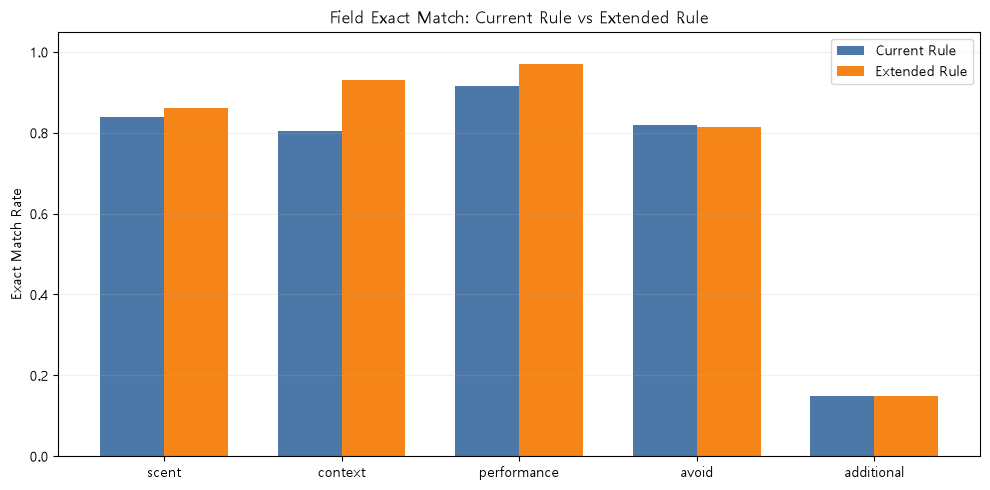

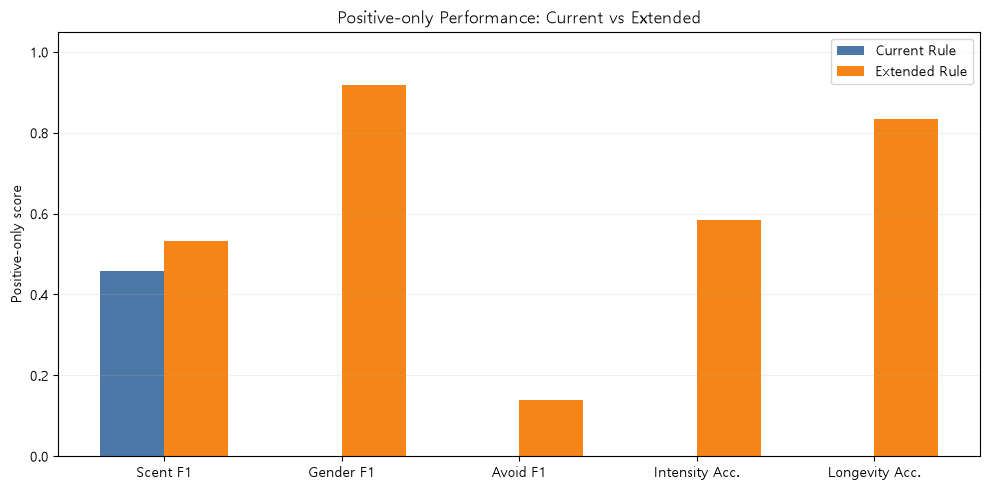

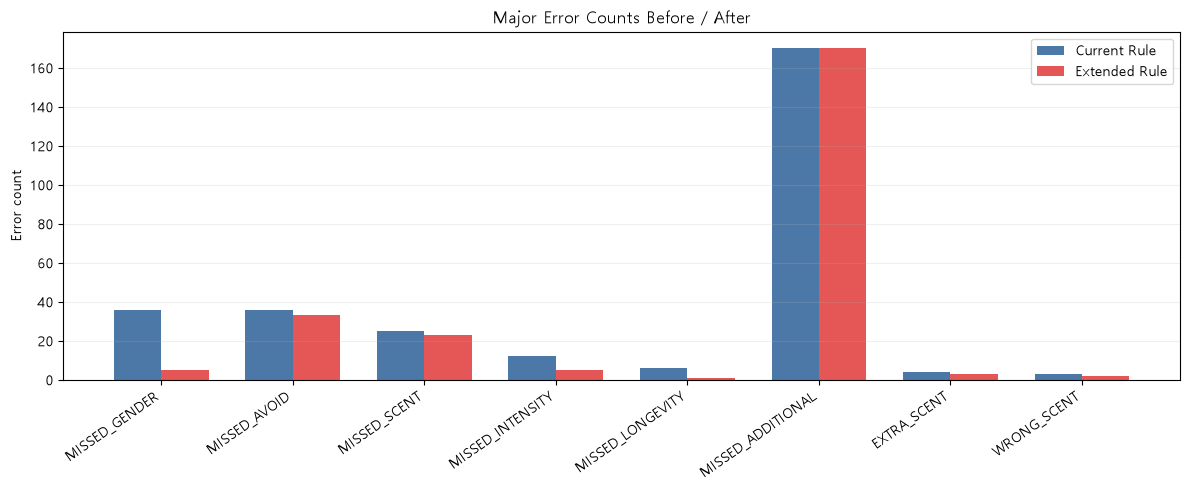

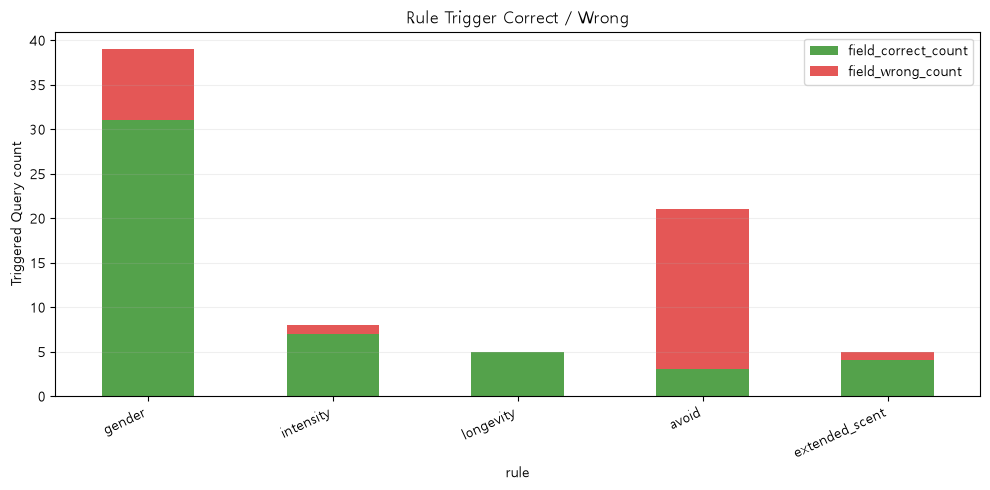

In [20]:
field_labels = ["scent", "context", "performance", "avoid", "additional"]
current_field = [baseline_metric[f"{field}_exact_match"] for field in field_labels]
extended_field = [extended_metric[f"{field}_exact_match"] for field in field_labels]
x = np.arange(len(field_labels)); width = 0.36
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, current_field, width, label="Current Rule", color="#4C78A8")
ax.bar(x + width/2, extended_field, width, label="Extended Rule", color="#F58518")
ax.set_xticks(x, field_labels); ax.set_ylim(0, 1.05); ax.set_ylabel("Exact Match Rate")
ax.set_title("Field Exact Match: Current Rule vs Extended Rule"); ax.legend(); ax.grid(axis="y", alpha=0.2)
plt.tight_layout(); plt.show()

positive_metric_specs = [
    ("Scent F1", "positive_scent_micro_f1"),
    ("Gender F1", "positive_gender_micro_f1"),
    ("Avoid F1", "positive_avoid_micro_f1"),
    ("Intensity Acc.", "positive_intensity_accuracy"),
    ("Longevity Acc.", "positive_longevity_accuracy"),
]
labels = [label for label, metric in positive_metric_specs if metric in baseline_metric and metric in extended_metric]
keys = [metric for label, metric in positive_metric_specs if metric in baseline_metric and metric in extended_metric]
x = np.arange(len(keys))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, [baseline_metric[k] for k in keys], width, label="Current Rule", color="#4C78A8")
ax.bar(x + width/2, [extended_metric[k] for k in keys], width, label="Extended Rule", color="#F58518")
ax.set_xticks(x, labels); ax.set_ylim(0, 1.05); ax.set_ylabel("Positive-only score")
ax.set_title("Positive-only Performance: Current vs Extended"); ax.legend(); ax.grid(axis="y", alpha=0.2)
plt.tight_layout(); plt.show()

major_errors = error_order
error_plot = error_delta_df.set_index("error_type").loc[major_errors]
x = np.arange(len(major_errors))
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, error_plot["baseline_count"], width, label="Current Rule", color="#4C78A8")
ax.bar(x + width/2, error_plot["extended_count"], width, label="Extended Rule", color="#E45756")
ax.set_xticks(x, major_errors, rotation=35, ha="right"); ax.set_ylabel("Error count")
ax.set_title("Major Error Counts Before / After"); ax.legend(); ax.grid(axis="y", alpha=0.2)
plt.tight_layout(); plt.show()

ax = trigger_diagnostics_df.set_index("rule")[["field_correct_count", "field_wrong_count"]].plot(
    kind="bar", stacked=True, figsize=(10, 5), color=["#54A24B", "#E45756"]
)
ax.set_ylabel("Triggered Query count"); ax.set_title("Rule Trigger Correct / Wrong")
ax.grid(axis="y", alpha=0.2); plt.xticks(rotation=25, ha="right"); plt.tight_layout(); plt.show()

## 21. Save Outputs

In [21]:
PREDICTIONS_PATH = OUTPUT_DIR / "14_extended_rule_stage1_predictions.csv"
EVALUATION_PATH = OUTPUT_DIR / "14_extended_rule_stage1_evaluation.csv"
ERRORS_PATH = OUTPUT_DIR / "14_extended_rule_stage1_errors.csv"
METRICS_PATH = OUTPUT_DIR / "14_extended_rule_stage1_metrics.csv"
COMPARISON_PATH = OUTPUT_DIR / "14_rule_comparison.csv"
ERROR_DELTA_PATH = OUTPUT_DIR / "14_error_delta.csv"
QUERY_CHANGE_PATH = OUTPUT_DIR / "14_query_change_analysis.csv"
TRIGGER_PATH = OUTPUT_DIR / "14_rule_trigger_diagnostics.csv"
SUMMARY_PATH = OUTPUT_DIR / "14_extended_rule_summary.md"

prediction_output = predictions_df.drop(columns=["trigger_rules", "parser_error"]).copy()
for column in ["pred_scent_preference", "pred_context", "pred_performance", "pred_avoid", "pred_additional_requirements"]:
    prediction_output[column] = prediction_output[column].map(json_text)

fixed_count = int(change_counts.get("FIXED", 0))
regressed_count = int(change_counts.get("REGRESSED", 0))
regressed_rows = query_change_df[query_change_df["change_type"].eq("REGRESSED")]
regressed_lines = "\n".join(
    f"- {row.query_id}: {row.query_text}" for row in regressed_rows.head(10).itertuples(index=False)
) or "- 없음"

field_regression_lines = [
    "| Field | Improved | Regressed | Same Correct | Same Wrong |",
    "|---|---:|---:|---:|---:|",
]
for field in ["scent", "gender", "intensity", "longevity", "avoid"]:
    counts = query_change_df[f"{field}_change"].value_counts()
    field_regression_lines.append(
        f"| {field} | {int(counts.get('IMPROVED', 0))} | {int(counts.get('REGRESSED', 0))} | "
        f"{int(counts.get('SAME_CORRECT', 0))} | {int(counts.get('SAME_WRONG', 0))} |"
    )

focus_metrics = [
    ("Overall Exact Match", "overall_exact_match"),
    ("Coverage (13번 scent/context 정의)", "any_condition_prediction_coverage"),
    ("Scent Positive-only Micro F1", "positive_scent_micro_f1"),
    ("Gender Positive-only Micro F1", "positive_gender_micro_f1"),
    ("Intensity Positive-only Accuracy", "positive_intensity_accuracy"),
    ("Longevity Positive-only Accuracy", "positive_longevity_accuracy"),
    ("Avoid Positive-only Micro F1", "positive_avoid_micro_f1"),
]
comparison_lines = ["| Metric | Current Rule | Extended Rule | Difference |", "|---|---:|---:|---:|"]
for label, metric in focus_metrics:
    if metric in baseline_metric and metric in extended_metric:
        current, extended = baseline_metric[metric], extended_metric[metric]
        comparison_lines.append(f"| {label} | {current:.2%} | {extended:.2%} | {extended-current:+.2%}p |")

error_focus = error_delta_df[error_delta_df["error_type"].isin(error_order)]
error_lines = ["| Error | Before | After | Difference |", "|---|---:|---:|---:|"] + [
    f"| {row.error_type} | {row.baseline_count} | {row.extended_count} | {row.difference:+d} |"
    for row in error_focus.itertuples(index=False)
]

summary_text = f"""# Stage 1 Extended Rule Evaluation

## 실험 목적

일반화 가능한 명시적 Rule만 확장했을 때 실제 사용자 자연어 200개를 어디까지 구조화할 수 있는지 측정했다.

## Extended Rule 범위

- Gender
- Intensity
- Longevity
- Avoid
- Direct Scent 일부

감성·장면·직업·상황 표현과 Additional Requirements는 임의 Feature로 변환하지 않았다.

## Baseline 비교

{chr(10).join(comparison_lines)}

Difference는 Extended Rule - Current Rule이며 `p`는 퍼센트포인트를 뜻한다.

## 주요 개선

- Overall Exact Match: {baseline_metric['overall_exact_match']:.2%} → {extended_metric['overall_exact_match']:.2%}
- FIXED Query: {fixed_count}개
- Gender Rule trigger: {int(trigger_diagnostics_df.set_index('rule').loc['gender', 'trigger_query_count'])}개
- Intensity Rule trigger: {int(trigger_diagnostics_df.set_index('rule').loc['intensity', 'trigger_query_count'])}개
- Longevity Rule trigger: {int(trigger_diagnostics_df.set_index('rule').loc['longevity', 'trigger_query_count'])}개
- Avoid Rule trigger: {int(trigger_diagnostics_df.set_index('rule').loc['avoid', 'trigger_query_count'])}개

## 주요 Regression

- REGRESSED Query: {regressed_count}개

{regressed_lines}

### Field별 변화

{chr(10).join(field_regression_lines)}

## 오류 변화

{chr(10).join(error_lines)}

## Rule로 해결되지 않은 영역

- MISSED_ADDITIONAL은 {int(component_counts.get('MISSED_ADDITIONAL', 0))}개 남았다.
- Additional Requirements를 점수 개선을 위해 감성·장면·가격·나이 등의 임의 Rule로 변환하지 않았다.
- Trigger가 작동한 Query의 정답 여부는 `14_rule_trigger_diagnostics.csv`에서 Rule별로 분리했다.

## 결론

Rule 확장으로 해결된 영역과 여전히 해결되지 않은 영역을 분리했다. 이 결과만으로 특정 후속 방식을 확정하지 않으며, 같은 평가 정의와 별도 외부 Query를 사용한 비교가 필요하다.
"""

prediction_output.to_csv(PREDICTIONS_PATH, index=False, encoding="utf-8-sig")
evaluation_df.to_csv(EVALUATION_PATH, index=False, encoding="utf-8-sig")
errors_df.to_csv(ERRORS_PATH, index=False, encoding="utf-8-sig")
metrics_df.to_csv(METRICS_PATH, index=False, encoding="utf-8-sig")
comparison_df.to_csv(COMPARISON_PATH, index=False, encoding="utf-8-sig")
error_delta_df.to_csv(ERROR_DELTA_PATH, index=False, encoding="utf-8-sig")
query_change_df.to_csv(QUERY_CHANGE_PATH, index=False, encoding="utf-8-sig")
trigger_diagnostics_df.to_csv(TRIGGER_PATH, index=False, encoding="utf-8-sig")
SUMMARY_PATH.write_text(summary_text, encoding="utf-8")

output_paths = [
    PREDICTIONS_PATH, EVALUATION_PATH, ERRORS_PATH, METRICS_PATH,
    COMPARISON_PATH, ERROR_DELTA_PATH, QUERY_CHANGE_PATH, TRIGGER_PATH, SUMMARY_PATH,
]
output_audit = []
for path in output_paths:
    rows = len(pd.read_csv(path)) if path.suffix == ".csv" else len(path.read_text(encoding="utf-8").splitlines())
    output_audit.append({"file": path.name, "rows": rows, "size_kb": path.stat().st_size / 1024})
display(pd.DataFrame(output_audit))

,file,rows,size_kb
0,14_extended_rule_stage1_predictions.csv,200,36.8613
1,14_extended_rule_stage1_evaluation.csv,200,81.4414
2,14_extended_rule_stage1_errors.csv,191,78.5078
3,14_extended_rule_stage1_metrics.csv,73,2.5889
4,14_rule_comparison.csv,72,3.7451
5,14_error_delta.csv,13,0.3408
6,14_query_change_analysis.csv,200,43.3418
7,14_rule_trigger_diagnostics.csv,5,0.2314
8,14_extended_rule_summary.md,77,2.4756


## 22. Final Summary

In [22]:
protected_hashes_after = {label: sha256_file(path) for label, path in PROTECTED_PATHS.items()}
if protected_hashes_before != protected_hashes_after:
    changed = [label for label in protected_hashes_before if protected_hashes_before[label] != protected_hashes_after[label]]
    raise RuntimeError(f"보호 파일이 변경됐습니다: {changed}")

assert len(prediction_output) == 200
assert len(evaluation_df) == 200
assert len(errors_df) == 200 - exact_match_count
assert not evaluation_df.isna().any().any()
assert prediction_output.columns.tolist() == [
    "query_id", "query_text", "pred_scent_preference", "pred_context",
    "pred_performance", "pred_avoid", "pred_additional_requirements",
]
assert all(path.is_file() for path in output_paths)

def metric_transition(metric):
    if metric not in baseline_metric or metric not in extended_metric:
        return "N/A"
    return f"{baseline_metric[metric]:.2%} → {extended_metric[metric]:.2%}"

print("1. Overall Exact Match:", metric_transition("overall_exact_match"))
print("2. Coverage (13번 정의):", metric_transition("any_condition_prediction_coverage"))
print("3. Scent Positive-only F1:", metric_transition("positive_scent_micro_f1"))
print("4. Gender Positive-only F1:", metric_transition("positive_gender_micro_f1"))
print("5. Intensity Positive-only Accuracy:", metric_transition("positive_intensity_accuracy"))
print("6. Longevity Positive-only Accuracy:", metric_transition("positive_longevity_accuracy"))
print("7. Avoid Positive-only F1:", metric_transition("positive_avoid_micro_f1"))
print("8. 주요 Error Count Before → After")
for row in error_delta_df[error_delta_df["error_type"].isin(error_order)].itertuples(index=False):
    print(f"   {row.error_type}: {row.baseline_count} → {row.extended_count}")
print(f"9. FIXED Query 수: {fixed_count}")
print(f"10. REGRESSED Query 수: {regressed_count}")
print("11. 생성한 파일 목록")
for path in output_paths:
    print(f"   - {path.relative_to(PROJECT_ROOT)}")
print(f"Parser 오류: {len(parser_errors_df)}")
print("보호 파일 해시 검증: 변경 없음")

1. Overall Exact Match: 1.50% → 4.50%
2. Coverage (13번 정의): 15.50% → 33.00%
3. Scent Positive-only F1: 45.90% → 53.12%
4. Gender Positive-only F1: 0.00% → 91.89%
5. Intensity Positive-only Accuracy: 0.00% → 58.33%
6. Longevity Positive-only Accuracy: 0.00% → 83.33%
7. Avoid Positive-only F1: 0.00% → 13.79%
8. 주요 Error Count Before → After
   MISSED_GENDER: 36 → 5
   MISSED_AVOID: 36 → 33
   MISSED_SCENT: 25 → 23
   MISSED_INTENSITY: 12 → 5
   MISSED_LONGEVITY: 6 → 1
   MISSED_ADDITIONAL: 170 → 170
   EXTRA_SCENT: 4 → 3
   WRONG_SCENT: 3 → 2
9. FIXED Query 수: 6
10. REGRESSED Query 수: 0
11. 생성한 파일 목록
   - analysis_outputs\14_extended_rule_stage1_predictions.csv
   - analysis_outputs\14_extended_rule_stage1_evaluation.csv
   - analysis_outputs\14_extended_rule_stage1_errors.csv
   - analysis_outputs\14_extended_rule_stage1_metrics.csv
   - analysis_outputs\14_rule_comparison.csv
   - analysis_outputs\14_error_delta.csv
   - analysis_outputs\14_query_change_analysis.csv
   - analysis_outpu